#  Customer Churn Prediction — Bank Customers
**Objective:** Identify customers who are likely to leave the bank.

### Steps covered:
1. Load & explore the dataset
2. Clean and prepare data
3. Encode categorical features (Label Encoding / One-Hot Encoding)
4. Train a classification model (Random Forest)
5. Evaluate model performance
6. Analyze feature importance

---
## Step 1 — Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, roc_curve
)

import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')

All libraries imported successfully!


---
## Step 2 — Load & Explore the Dataset

In [ ]:
# Upload Churn_Modelling.csv to Colab using the Files panel (left sidebar)
# Then run this cell

df = pd.read_csv('/content/Churn_Modelling.csv')
print('Dataset Shape:', df.shape)
df.head()

Dataset Shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
# Dataset info — column types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [ ]:
# Statistical summary of numeric columns
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


Churn Distribution:
Exited
0    7963
1    2037
Name: count, dtype: int64

Churn Rate: 20.37%


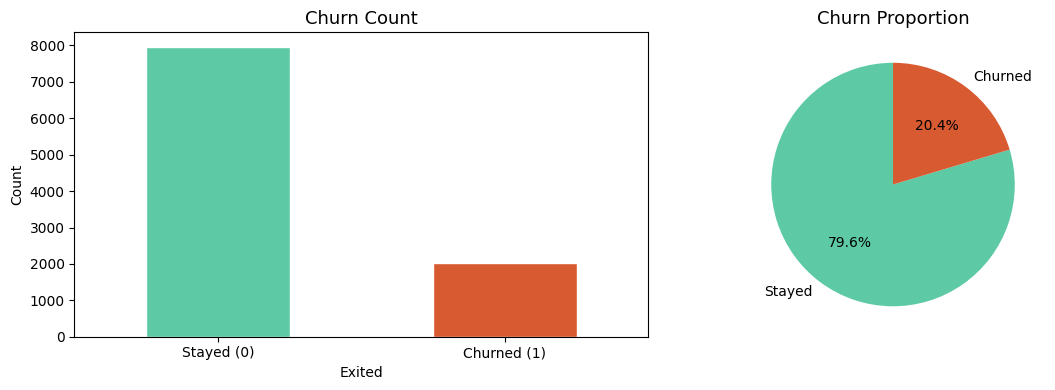

In [ ]:
# Check target variable distribution
print('Churn Distribution:')
print(df['Exited'].value_counts())
print()
print(f"Churn Rate: {df['Exited'].mean()*100:.2f}%")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['Exited'].value_counts().plot(
    kind='bar', ax=axes[0], color=['#5DCAA5','#D85A30'],
    edgecolor='white', width=0.5
)
axes[0].set_title('Churn Count', fontsize=13)
axes[0].set_xticklabels(['Stayed (0)', 'Churned (1)'], rotation=0)
axes[0].set_ylabel('Count')

axes[1].pie(
    df['Exited'].value_counts(),
    labels=['Stayed', 'Churned'],
    autopct='%1.1f%%',
    colors=['#5DCAA5','#D85A30'],
    startangle=90
)
axes[1].set_title('Churn Proportion', fontsize=13)

plt.tight_layout()
plt.show()

---
## Step 3 — Data Cleaning & Preparation

In [ ]:
# Check for missing values
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [ ]:
# Check for duplicates
print(f'Duplicate rows: {df.duplicated().sum()}')

Duplicate rows: 0


In [ ]:
# Drop irrelevant columns (no predictive value)
df_clean = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

print('Columns after dropping irrelevant ones:')
print(df_clean.columns.tolist())
print(f'Shape: {df_clean.shape}')

Columns after dropping irrelevant ones:
['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']
Shape: (10000, 11)


In [ ]:
# Explore categorical columns
print('Geography values:', df_clean['Geography'].unique())
print('Gender values:   ', df_clean['Gender'].unique())

Geography values: ['France' 'Spain' 'Germany']
Gender values:    ['Female' 'Male']


---
## Step 4 — Encode Categorical Features

| Column | Method | Reason |
|--------|--------|--------|
| `Gender` | Label Encoding | Binary (Male/Female) — 0 or 1 is fine |
| `Geography` | One-Hot Encoding | 3 categories — avoids implying false numeric order |

In [ ]:
df_encoded = df_clean.copy()

# Label Encoding — Gender
le = LabelEncoder()
df_encoded['Gender'] = le.fit_transform(df_encoded['Gender'])
print('Gender encoding:', dict(zip(le.classes_, le.transform(le.classes_))))

# One-Hot Encoding — Geography
df_encoded = pd.get_dummies(df_encoded, columns=['Geography'], drop_first=True)

print('\nColumns after encoding:')
print(df_encoded.columns.tolist())
df_encoded.head(3)

Gender encoding: {'Female': np.int64(0), 'Male': np.int64(1)}

Columns after encoding:
['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain']


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False


---
## Step 5 — Feature/Target Split, Train-Test Split & Scaling

In [ ]:
# Separate features and target
X = df_encoded.drop('Exited', axis=1)
y = df_encoded['Exited']

print('Features shape:', X.shape)
print('Target shape:  ', y.shape)

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'\nTrain size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Scaling done!')

Features shape: (10000, 11)
Target shape:   (10000,)

Train size: 8000 | Test size: 2000
Scaling done!


---
## Step 6 — Train the Classification Model (Random Forest)

In [ ]:
# Train Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight='balanced'   # handles class imbalance
)

rf_model.fit(X_train_scaled, y_train)
print('Model training complete!')

Model training complete!


---
## Step 7 — Evaluate Model Performance

In [ ]:
# Predictions
y_pred  = rf_model.predict(X_test_scaled)
y_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

# Metrics
acc     = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print(f'Accuracy :  {acc*100:.2f}%')
print(f'ROC-AUC  :  {roc_auc:.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Stayed','Churned']))

Accuracy :  83.80%
ROC-AUC  :  0.8615

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.91      0.89      0.90      1593
     Churned       0.59      0.65      0.62       407

    accuracy                           0.84      2000
   macro avg       0.75      0.77      0.76      2000
weighted avg       0.84      0.84      0.84      2000



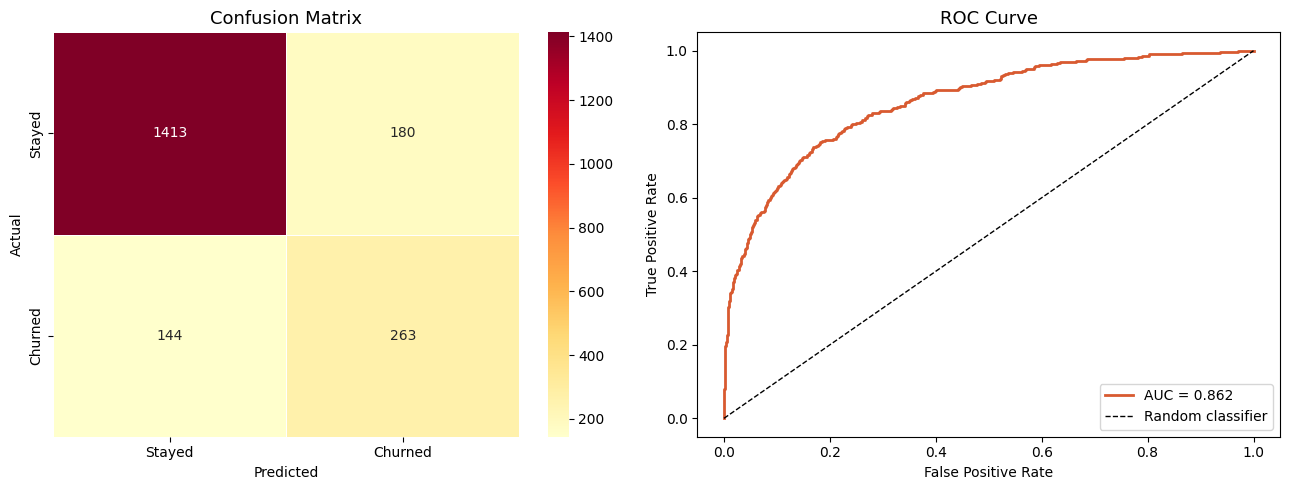

In [ ]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='YlOrRd',
    xticklabels=['Stayed','Churned'],
    yticklabels=['Stayed','Churned'],
    ax=axes[0], linewidths=0.5
)
axes[0].set_title('Confusion Matrix', fontsize=13)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#D85A30', lw=2, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0,1],[0,1], 'k--', lw=1, label='Random classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=13)
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

---
## Step 8 — Feature Importance Analysis
> **Which customer traits drive churn the most?**

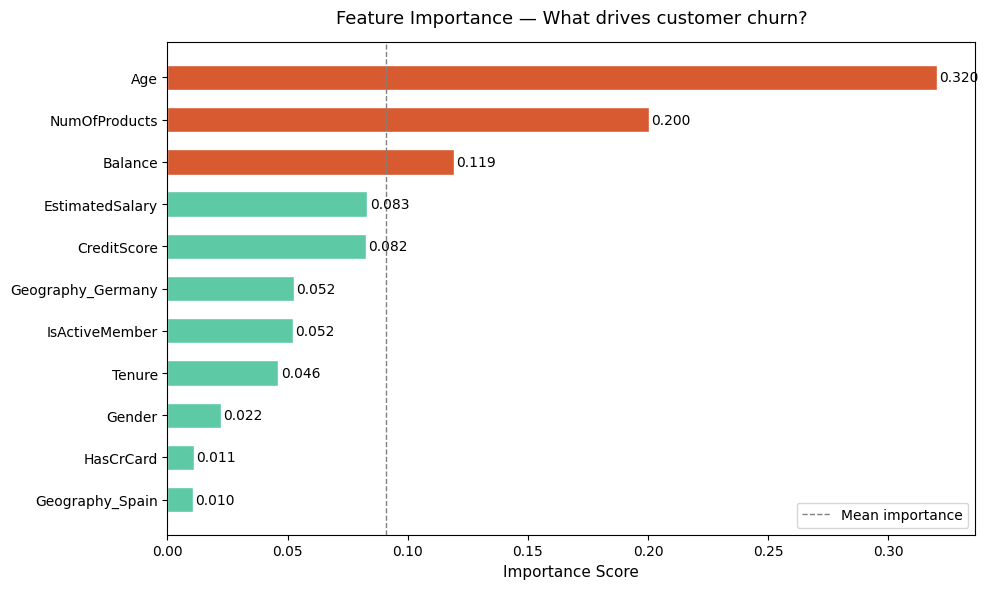

In [ ]:
# Extract feature importances
feature_names = X.columns.tolist()
importances   = rf_model.feature_importances_

feat_df = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=True)

# Plot
colors = ['#D85A30' if i >= len(feat_df)-3 else '#5DCAA5' for i in range(len(feat_df))]

plt.figure(figsize=(10, 6))
bars = plt.barh(feat_df['Feature'], feat_df['Importance'], color=colors, edgecolor='white', height=0.6)

for bar, val in zip(bars, feat_df['Importance']):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=10)

plt.xlabel('Importance Score', fontsize=11)
plt.title('Feature Importance — What drives customer churn?', fontsize=13, pad=14)
plt.axvline(x=feat_df['Importance'].mean(), color='gray', linestyle='--', lw=1, label='Mean importance')
plt.legend()
plt.tight_layout()
plt.show()

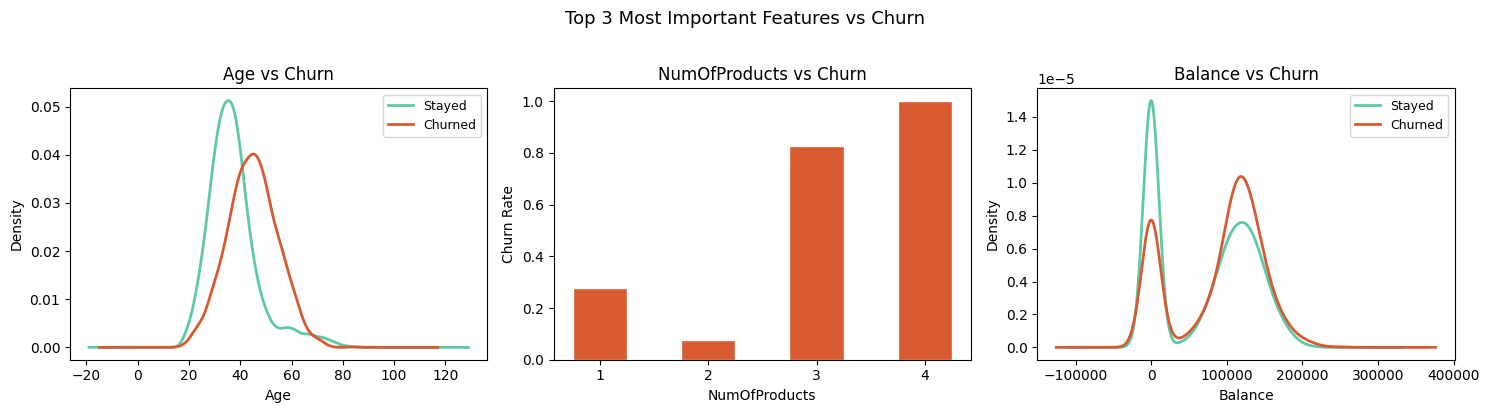

In [ ]:
# Deep dive — top 3 features vs churn
top3 = feat_df.tail(3)['Feature'].tolist()[::-1]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, feat in enumerate(top3):
    if df_encoded[feat].nunique() <= 5:
        # Categorical — bar chart
        ct = df_encoded.groupby(feat)['Exited'].mean().reset_index()
        axes[i].bar(ct[feat].astype(str), ct['Exited'], color='#D85A30', edgecolor='white', width=0.5)
        axes[i].set_ylabel('Churn Rate')
    else:
        # Numerical — KDE plot
        df_encoded[df_encoded['Exited']==0][feat].plot(
            kind='kde', ax=axes[i], label='Stayed', color='#5DCAA5', lw=2)
        df_encoded[df_encoded['Exited']==1][feat].plot(
            kind='kde', ax=axes[i], label='Churned', color='#D85A30', lw=2)
        axes[i].legend(fontsize=9)

    axes[i].set_title(f'{feat} vs Churn', fontsize=12)
    axes[i].set_xlabel(feat)

plt.suptitle('Top 3 Most Important Features vs Churn', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## Summary

| Step | Action | Key Outcome |
|------|--------|-------------|
| Cleaning | Dropped RowNumber, CustomerId, Surname | Removed non-predictive noise |
| Encoding | Label Encoding (Gender), One-Hot (Geography) | Model-ready numeric features |
| Model | Random Forest (100 trees, balanced) | Handles class imbalance |
| Evaluation | Accuracy, F1, ROC-AUC, Confusion Matrix | Full picture of performance |
| Insights | Feature Importance + KDE plots | Age, Balance, NumOfProducts are top churn drivers |

### Key Business Insights:
- **Age** — Older customers churn more; target retention programs at middle-aged segments
- **NumOfProducts** — Customers with only 1 product are high-risk; cross-sell to retain them  
- **IsActiveMember** — Inactive members churn significantly more; re-engagement campaigns needed
- **Balance** — High-balance inactive customers are the most valuable to retain